In [1]:
import bw2data, bw2io
import bw2calc
import numpy as np
import pandas as pd
import xarray as xr
import os
import sys

In [2]:
sys.path.append('/Users/susierwu/dpLCA_main/') 
from utils import *
from utils.newbw2method_dpLCIA import * 

In [3]:
bw2data.projects.set_current('iveo_v1')

In [4]:
# before adding the fixed AGWP[CO2] version, already have the pGWP100 from dpAGWP[CO2]
[m for m in bw2data.methods if 'GWP100' in str(m) and  'SSP119' in str(m) and 'test' not in str(m)]

[('IPCC 2021 - dpCFsSSP119_MY2030 - year100', 'climate change', 'pGWP100'),
 ('IPCC 2021 - dpCFsSSP119_MY2040 - year100', 'climate change', 'pGWP100'),
 ('IPCC 2021 - dpCFsSSP119_MY2050 - year100', 'climate change', 'pGWP100')]

In [5]:
mybio = bw2data.Database("biosphere3")
len(mybio)

4709

### read in pre-calculated .nc LCIA dataset, d-IRF for a new IRF metric calculation

In [6]:
#cf_point = xr.open_dataset('data/CF_GWP1_100_perSSP_MY_majorghgs.nc')
cf_point_fixedco2 = xr.open_dataset('../../AGWPCO2_fixed_IPCCAR6/output_dpGWP_fixedCO2/CF_GWP1_100_perSSP_MY_majorghgs.nc')
cf_point_fixedco2

<xarray.Dataset>
Dimensions:    (Year: 100, ModelYear: 4, SSP: 3)
Coordinates:
  * Year       (Year) int32 1 2 3 4 5 6 7 8 9 10 ... 92 93 94 95 96 97 98 99 100
  * ModelYear  (ModelYear) int32 2020 2030 2040 2050
  * SSP        (SSP) object '119' '245' '585'
Data variables:
    CO2_GWP    (SSP, ModelYear, Year) float64 ...
    CH4_GWP    (SSP, ModelYear, Year) float64 ...
    N2O_GWP    (SSP, ModelYear, Year) float64 ...

### read in premise_GWP, all minor_ghg using static amount 

In [7]:
prem_gwp_dfraw = pd.read_excel("../premise_gwp/lcia_gwp2021_100a_w_bio.xlsx")
prem_gwp_dfraw.head()

,name,categories,amount
0,Bromopropane,air::unspecified,0.052
1,Butane,air::urban air close to ground,0.006
2,Butane,air::non-urban air or from high stacks,0.006
3,Butane,"air::low population density, long-term",0.006
4,Butane,air::lower stratosphere + upper troposphere,0.006


### calling the assign_dpGWP class, see what it looks like for final CF

In [8]:
xx = assign_dpGWP(premise_gwp100_inputdf = prem_gwp_dfraw, cf_inputds = cf_point_fixedco2, ssp = '119', fairMY = 2030 )
minorg, allg = xx.get_minorand_allGHG()
cc = xx.prep_empty_C(allg)
#cc.head()
pcc = xx.assign_minorghg_to_C_GWP100(cc, minorg)
fcc = xx.assign_majorghg_dCC(pcc)
fcc

,Bromopropane,Butane,"Carbon monoxide, fossil","Carbon monoxide, from soil or biomass stock","Carbon monoxide, non-fossil",Chloroform,Ethane,"Ethane, 1,1,1,2-tetrafluoro-, HFC-134a","Ethane, 1,1,1-trichloro-, HCFC-140","Ethane, 1,1,1-trifluoro-, HFC-143a",...,"Carbon dioxide, non-fossil","Carbon dioxide, in air","Carbon dioxide, to soil or biomass stock","Carbon dioxide, from soil or biomass stock","Carbon dioxide, fossil","Carbon dioxide, non-fossil, resource correction","Methane, from soil or biomass stock","Methane, fossil","Methane, non-fossil",Dinitrogen monoxide
GWP1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.144749,-1.144749,-1.144749,1.144749,1.144749,-1.144749,129.352601,129.352601,129.352601,184.469938
GWP2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.144749,-1.144749,-1.144749,1.144749,1.144749,-1.144749,127.959994,127.959994,127.959994,189.550487
GWP3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.144749,-1.144749,-1.144749,1.144749,1.144749,-1.144749,126.326546,126.326546,126.326546,194.249359
GWP4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.144749,-1.144749,-1.144749,1.144749,1.144749,-1.144749,124.507922,124.507922,124.507922,198.568767
GWP5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.144749,-1.144749,-1.144749,1.144749,1.144749,-1.144749,122.475229,122.475229,122.475229,202.518172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GWP96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.144749,-1.144749,-1.144749,1.144749,1.144749,-1.144749,29.521723,29.521723,29.521723,222.463586
GWP97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.144749,-1.144749,-1.144749,1.144749,1.144749,-1.144749,29.263837,29.263837,29.263837,221.978137
GWP98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.144749,-1.144749,-1.144749,1.144749,1.144749,-1.144749,29.010523,29.010523,29.010523,221.490539
GWP99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.144749,-1.144749,-1.144749,1.144749,1.144749,-1.144749,28.761657,28.761657,28.761657,221.003220


### run MY2030/2040&2050 and all SSP together, for GWP we only have pGWP100 now, using static GWP100 for minorGHGs

### DO NOT overwrite the pGWP100 created before, using new IM name as :: 
- revised function:: prep_final_dCC_bw2method (self, data, gwp_method = None):  gwp_method = 'fixed_CO2'

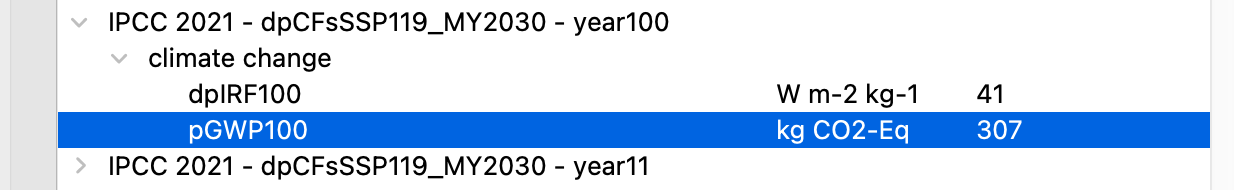

In [9]:
for mmy in [2030, 2040, 2050]: 
    for sp in ['119', '245', '585']: 
        xx = assign_dpGWP(premise_gwp100_inputdf = prem_gwp_dfraw, cf_inputds = cf_point_fixedco2, ssp = sp, fairMY = mmy, GWP100_only = True )
        minorg, allg = xx.get_minorand_allGHG()
        emt_C =  xx.prep_empty_C(allg)
        fullminor_C = xx.assign_minorghg_to_C_GWP100(emt_C, minorg )
        #print(fullminor_C.head() )
        full_allC = xx.assign_majorghg_dCC(fullminor_C)
        data = xx.prep_data_for_bw2method (full_allC, mybio = bw2data.Database("biosphere3"))
        print(len(data))
        xx.prep_final_dCC_bw2method (data, gwp_method = 'with fixed AGWPCO2')

start preparing data to be assigned as new bw2data.methods, for SSP 119 and fair_MY2030
1
 start creating new method, with name: IPCC 2021 - dpCFsSSP119_MY2030 - year
finishing preparing new methods, method name : ('IPCC 2021 - dpCFsSSP119_MY2030 - year100', 'climate change', 'pGWP100 with fixed AGWPCO2')
start preparing data to be assigned as new bw2data.methods, for SSP 245 and fair_MY2030
1
 start creating new method, with name: IPCC 2021 - dpCFsSSP245_MY2030 - year
finishing preparing new methods, method name : ('IPCC 2021 - dpCFsSSP245_MY2030 - year100', 'climate change', 'pGWP100 with fixed AGWPCO2')
start preparing data to be assigned as new bw2data.methods, for SSP 585 and fair_MY2030
1
 start creating new method, with name: IPCC 2021 - dpCFsSSP585_MY2030 - year
finishing preparing new methods, method name : ('IPCC 2021 - dpCFsSSP585_MY2030 - year100', 'climate change', 'pGWP100 with fixed AGWPCO2')
start preparing data to be assigned as new bw2data.methods, for SSP 119 and fai

In [10]:
[m for m in bw2data.methods if 'pGWP100' in str(m)]

[('IPCC 2021 - dpCFsSSP119_MY2030 - year100', 'climate change', 'pGWP100'),
 ('IPCC 2021 - dpCFsSSP245_MY2030 - year100', 'climate change', 'pGWP100'),
 ('IPCC 2021 - dpCFsSSP585_MY2030 - year100', 'climate change', 'pGWP100'),
 ('IPCC 2021 - dpCFsSSP119_MY2040 - year100', 'climate change', 'pGWP100'),
 ('IPCC 2021 - dpCFsSSP245_MY2040 - year100', 'climate change', 'pGWP100'),
 ('IPCC 2021 - dpCFsSSP585_MY2040 - year100', 'climate change', 'pGWP100'),
 ('IPCC 2021 - dpCFsSSP119_MY2050 - year100', 'climate change', 'pGWP100'),
 ('IPCC 2021 - dpCFsSSP245_MY2050 - year100', 'climate change', 'pGWP100'),
 ('IPCC 2021 - dpCFsSSP585_MY2050 - year100', 'climate change', 'pGWP100'),
 ('IPCC 2021 - dpCFsSSP119_MY2030 - year100',
  'climate change',
  'pGWP100 with fixed AGWPCO2'),
 ('IPCC 2021 - dpCFsSSP245_MY2030 - year100',
  'climate change',
  'pGWP100 with fixed AGWPCO2'),
 ('IPCC 2021 - dpCFsSSP585_MY2030 - year100',
  'climate change',
  'pGWP100 with fixed AGWPCO2'),
 ('IPCC 2021 - dpCF